# CMJ jump height Notebook pipeline


## 1. Imports

In [1]:
import os
import re
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

from utilities.utils import flip_axis, get_reps, ts_jump_height
import utilities.PTM as PTM 

%matplotlib inline

## 2. Configuration

In [ ]:
FILE      = "keypoints/cmj/P03_CMJBL_FRONT.txt"   # One file to work on
FPS       = 30
WIDTH     = 1920     
HEIGHT    = 1080     
REST_SEC  = 0.5      

# Settings for GET REPS function
REWIND, FORWARD, D_SEC, EXPECTED_REPS = 1, 1, 5, 3 # How many seconds before and after jump peak to use, min sections between peaks, expected reps

# Subject heights (metres), in order P03 -> P18 (your metre_heights array)
heights = [1.84, 1.5, 1.725, 1.73, 1.635, 1.67, 1.71, 1.65,
            1.8, 1.88, 1.62, 1.85, 1.915, 1.78, 1.84, 1.76]

SUBJECT_HEIGHTS = {f"P{i:02d}": h for i, h in zip(range(3, 19), heights)}

# Find particapend name and height
m = re.search(r"P\d{2}", os.path.basename(FILE))
PARTICIPANT = m.group(0) if m else None
SUBJECT_HEIGHT_M = SUBJECT_HEIGHTS.get(PARTICIPANT)
print(f"file : {os.path.basename(FILE)}")
print(f"participant : {PARTICIPANT}")
print(f"height : {SUBJECT_HEIGHT_M}")

file        : P03_CMJBL_FRONT.txt
participant : P03
height      : 1.84 m


## 3. Load the file

In [ ]:
# I think does the same thing as posedata.py -> need to updatae

POSE_LANDMARKS = [
    "NOSE","LEFT_EYE_INNER","LEFT_EYE","LEFT_EYE_OUTER","RIGHT_EYE_INNER",
    "RIGHT_EYE","RIGHT_EYE_OUTER","LEFT_EAR","RIGHT_EAR","MOUTH_LEFT",
    "MOUTH_RIGHT","LEFT_SHOULDER","RIGHT_SHOULDER","LEFT_ELBOW","RIGHT_ELBOW",
    "LEFT_WRIST","RIGHT_WRIST","LEFT_PINKY","RIGHT_PINKY","LEFT_INDEX",
    "RIGHT_INDEX","LEFT_THUMB","RIGHT_THUMB","LEFT_HIP","RIGHT_HIP",
    "LEFT_KNEE","RIGHT_KNEE","LEFT_ANKLE","RIGHT_ANKLE","LEFT_HEEL",
    "RIGHT_HEEL","LEFT_FOOT_INDEX","RIGHT_FOOT_INDEX",
]
COORDS = ("x", "y", "z")
PER_FRAME = len(POSE_LANDMARKS) * len(COORDS)   # 99


def load_pose_file(path):
    raw = open(path).read().replace(",", " ")
    frames, cur = [], []
    for tok in raw.split():
        if tok == "-":
            if cur:
                frames.append(cur); cur = []
        else:
            cur.append(float(tok))
    if cur:
        frames.append(cur)
    bad = [(i, len(f)) for i, f in enumerate(frames) if len(f) != PER_FRAME]
    if bad:
        raise ValueError(f"{len(bad)} frame(s) not {PER_FRAME} long: {bad[:5]}")
    arr = np.array(frames).reshape(len(frames), len(POSE_LANDMARKS), len(COORDS))
    return pd.DataFrame({f"{n}_{c}": arr[:, i, j]
                         for i, n in enumerate(POSE_LANDMARKS)
                         for j, c in enumerate(COORDS)})


df = load_pose_file(FILE)
print(df.shape, "(frames, columns)")

(1122, 99) (frames, columns)


## 4. Normalized -> pixels, build hip & toe signals

Multiply x by WIDTH and y by HEIGHT. Then hip = midpoint of L/R hip, toe =
right foot index. `flip_axis` makes up positive. We smooth the hip for
segmentation and the toe for the height read (its `max` drives the result, so a
single noisy frame shouldn't set it).

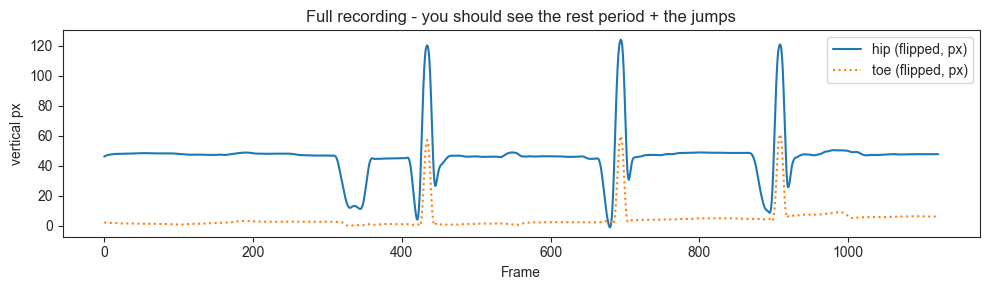

In [4]:
px = df.copy()
for c in px.columns:
    if c.endswith("_x"):
        px[c] *= WIDTH
    elif c.endswith("_y"):
        px[c] *= HEIGHT
    # leave _z (already relative) alone

hip = np.column_stack([(px["LEFT_HIP_x"] + px["RIGHT_HIP_x"]) / 2,
                       (px["LEFT_HIP_y"] + px["RIGHT_HIP_y"]) / 2])
toe = px[["RIGHT_FOOT_INDEX_x", "RIGHT_FOOT_INDEX_y"]].to_numpy()

hip_y = savgol_filter(flip_axis(hip.copy())[:, 1], 11, 2)   # up positive
toe_y = savgol_filter(flip_axis(toe.copy())[:, 1], 11, 2)

fig, ax = plt.subplots(figsize=(10, 3), dpi=100)
ax.plot(hip_y, label="hip (flipped, px)")
ax.plot(toe_y, ":", label="toe (flipped, px)")
ax.set_xlabel("Frame"); ax.set_ylabel("vertical px"); ax.legend()
ax.set_title("Full recording - you should see the rest period + the jumps")
plt.tight_layout(); plt.show()

## 5. Segment into reps

`get_reps` finds the jump peaks and windows each one (1 s before, 1 s after).
The vertical lines should bracket each jump.

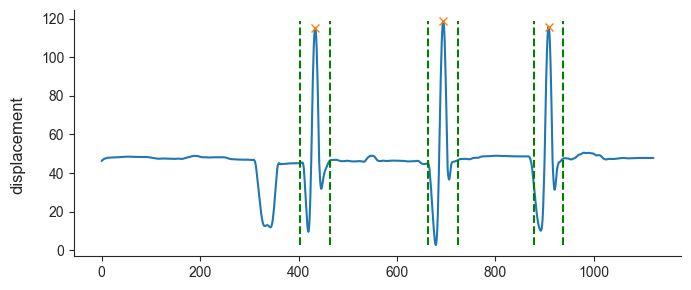

reps found: 3  (expected 3)


In [5]:
segs, reps = get_reps(hip_y, fps=FPS, rewind=REWIND, forward=FORWARD,
                      d=D_SEC, expected_reps=EXPECTED_REPS, plot_peaks=True)
print(f"reps found: {len(reps)}  (expected {EXPECTED_REPS})")

## 6. One anthropometric scale for this subject

From the standing rest frames: estimate body height in pixels from the right
leg + trunk (MediaPipe has no neck landmark, so neck = mid-shoulder), using the
reference's `(8/6) x (tibia + femur + trunk)` rule. Then

`mm_per_px = real_height_mm / pixel_body_height`.

One value, applied to every rep - never per rep (that was the source of the
1.4-1.9x scale wobble earlier). The wiring check below must return the known
height. `pixel_body_height` should be roughly 0.5-0.9 of the frame height; if
it's wildly off, the WIDTH/HEIGHT orientation is probably wrong.

In [6]:
rest_n = int(REST_SEC * FPS)

def point(name):
    return np.array([np.median(px[f"{name}_x"][:rest_n]),
                     np.median(px[f"{name}_y"][:rest_n])])

heel  = point("RIGHT_HEEL")
knee  = point("RIGHT_KNEE")
hip_r = point("RIGHT_HIP")
midhip = (point("LEFT_HIP") + point("RIGHT_HIP")) / 2
neck   = (point("LEFT_SHOULDER") + point("RIGHT_SHOULDER")) / 2

tibia = np.linalg.norm(heel - knee)
femur = np.linalg.norm(hip_r - knee)
trunk = np.linalg.norm(midhip - neck)
pixel_body_height = (8 * (tibia + femur + trunk)) / 6

mm_px = (SUBJECT_HEIGHT_M * 1000) / pixel_body_height
print(f"pixel_body_height : {pixel_body_height:.0f} px  ({pixel_body_height/HEIGHT:.0%} of frame)")
print(f"mm_per_px         : {mm_px:.3f} mm/px")
print(f"wiring check      : {mm_px*pixel_body_height/1000:.3f} m  (should equal {SUBJECT_HEIGHT_M})")

pixel_body_height : 415 px  (38% of frame)
mm_per_px         : 4.436 mm/px
wiring check      : 1.840 m  (should equal 1.84)


## 7. Jump height per rep

For each rep: slice the matching toe window, zero it to its own minimum,
multiply by the subject scale, and read height with `ts_jump_height` (cm).

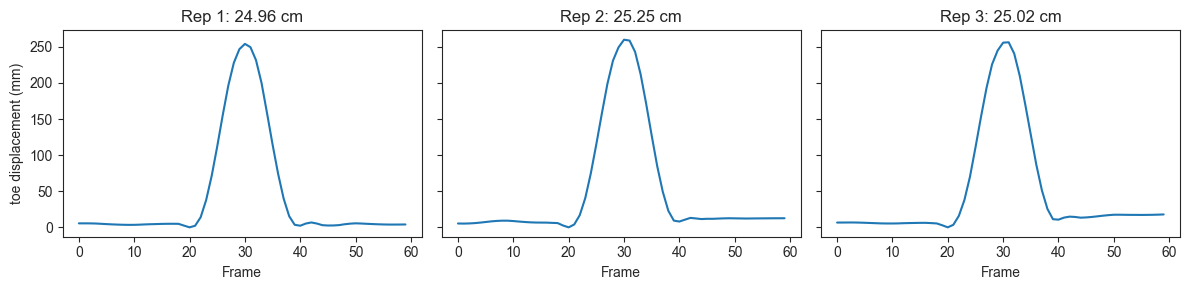

P03 heights (cm): [24.96 25.25 25.02]
mean = 25.1 cm   best = 25.2 cm   rep std = 0.12 cm


In [ ]:
results = []
fig, axs = plt.subplots(1, len(reps), figsize=(4 * len(reps), 3),
                        dpi=100, sharey=True)
if len(reps) == 1:
    axs = [axs]

for i, seg in enumerate(segs):
    s, e = int(seg[0]), int(seg[1])
    jump = toe_y[s:e].copy()
    jump -= jump.min()          # zero to rest
    jump_mm = jump * mm_px      # px -> mm 
    h = ts_jump_height(jump_mm, fps=FPS)
    results.append(h)
    axs[i].plot(jump_mm)
    axs[i].set_title(f"Rep {i+1}: {h} cm")
    axs[i].set_xlabel("Frame")
axs[0].set_ylabel("toe displacement (mm)")
plt.tight_layout(); plt.show()

heights = np.array(results)
print(f"{PARTICIPANT} heights (cm): {heights}")
print(f"mean = {heights.mean():.1f} cm   best = {heights.max():.1f} cm   "
      f"rep std = {heights.std():.2f} cm")

## 9. Optional: gravity scale for comparison

The noisy method, kept only as a contrast. Expect it to disagree, especially
its rep-to-rep `mm_px`.

In [8]:
print("rep | height_method (cm) | gravity_method (cm) | gravity mm_px")
for i, (seg, rep) in enumerate(zip(segs, reps)):
    s, e = int(seg[0]), int(seg[1])
    jump = toe_y[s:e].copy(); jump -= jump.min()
    h_height = ts_jump_height(jump * mm_px, fps=FPS)
    try:
        g_mmpx = PTM.mm_per_px(rep, fps=FPS)
        h_grav = ts_jump_height(jump * g_mmpx, fps=FPS)
        print(f" {i+1}  |   {h_height:5.1f}            |   {h_grav:7.1f}          | {g_mmpx:.1f}")
    except Exception as ex:
        print(f" {i+1}  |   {h_height:5.1f}            |   failed: {str(ex)[:30]}")

rep | height_method (cm) | gravity_method (cm) | gravity mm_px
 1  |    25.0            |      23.9          | 4.2
 2  |    25.2            |      25.8          | 4.5
 3  |    25.0            |      26.8          | 4.7
